<a href="https://colab.research.google.com/github/FaizunKarim/DTS-Data-Scientist-Supervisor/blob/main/LightGBM%20Breast%20Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import joblib
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from ipywidgets import widgets
from IPython.display import display, HTML
from google.colab import files

## Langkah 1: Deskripsi Data & Data Understanding

In [52]:
breast_cancer = load_breast_cancer()
X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y = pd.Series(breast_cancer.target)

print("--- Dataset Breast Cancer ---")
print(f"Dimensi Dataset: {X.shape}")

print("\n5 Baris Pertama Data Fitur:")
print(X.head())

df = pd.DataFrame(data=breast_cancer.data, columns=breast_cancer.feature_names)
df['target'] = breast_cancer.target

print("\nInformasi Ringkas Dataset:")
df.info()

print("\nDeskripsi Statistik Data:")
print(X.describe())

print("\nDistribusi Kelas Variabel Target:")
print(y.value_counts())
print(f"\n0: Malignant, 1: Benign")

print("\nKorelasi Antar Variabel (5 baris pertama):")
print(X.corr().head())

--- Dataset Breast Cancer ---
Dimensi Dataset: (569, 30)

5 Baris Pertama Data Fitur:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mea

## Langkah 2: Eksplorasi Data (Visualisasi)

### Histogram untuk Distribusi Setiap Variabel Fitur

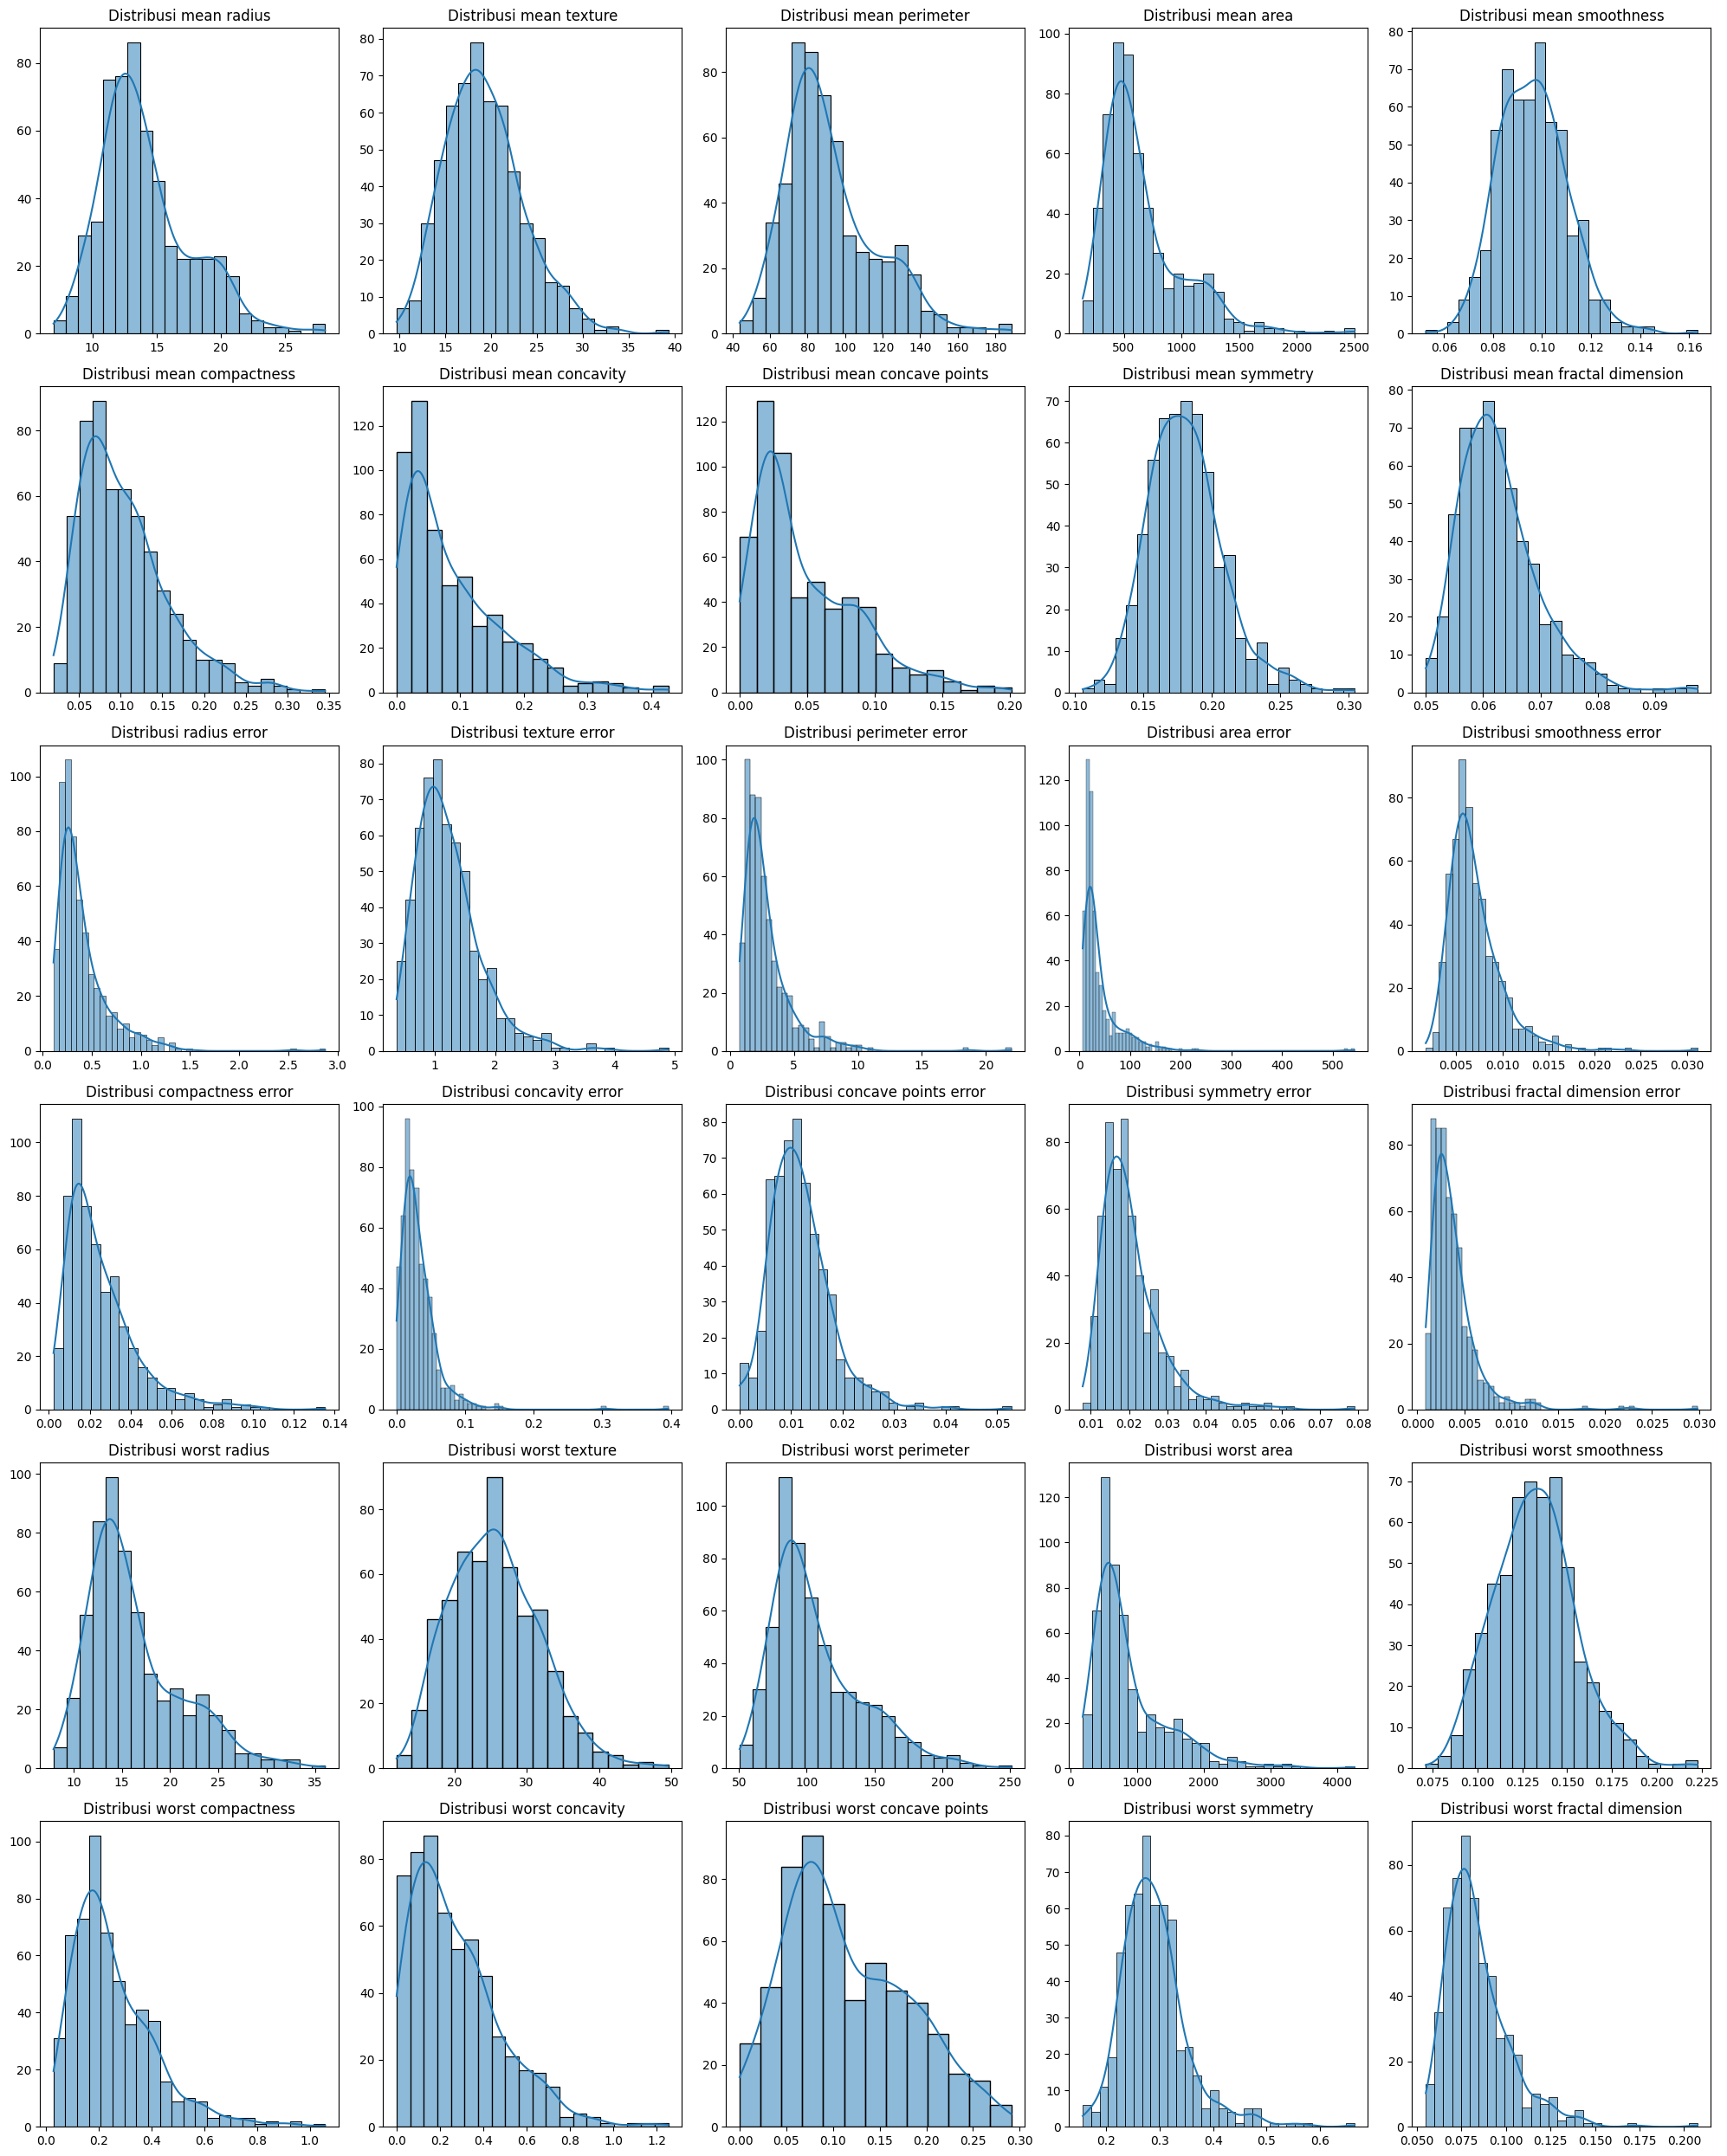

In [53]:
plt.figure(figsize=(20, 25))
for i, column in enumerate(X.columns):
    plt.subplot(6, 5, i + 1)
    sns.histplot(X[column], kde=True)
    plt.title(f'Distribusi {column}')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### Box Plot untuk Melihat Sebaran Data dan Mengidentifikasi Outlier

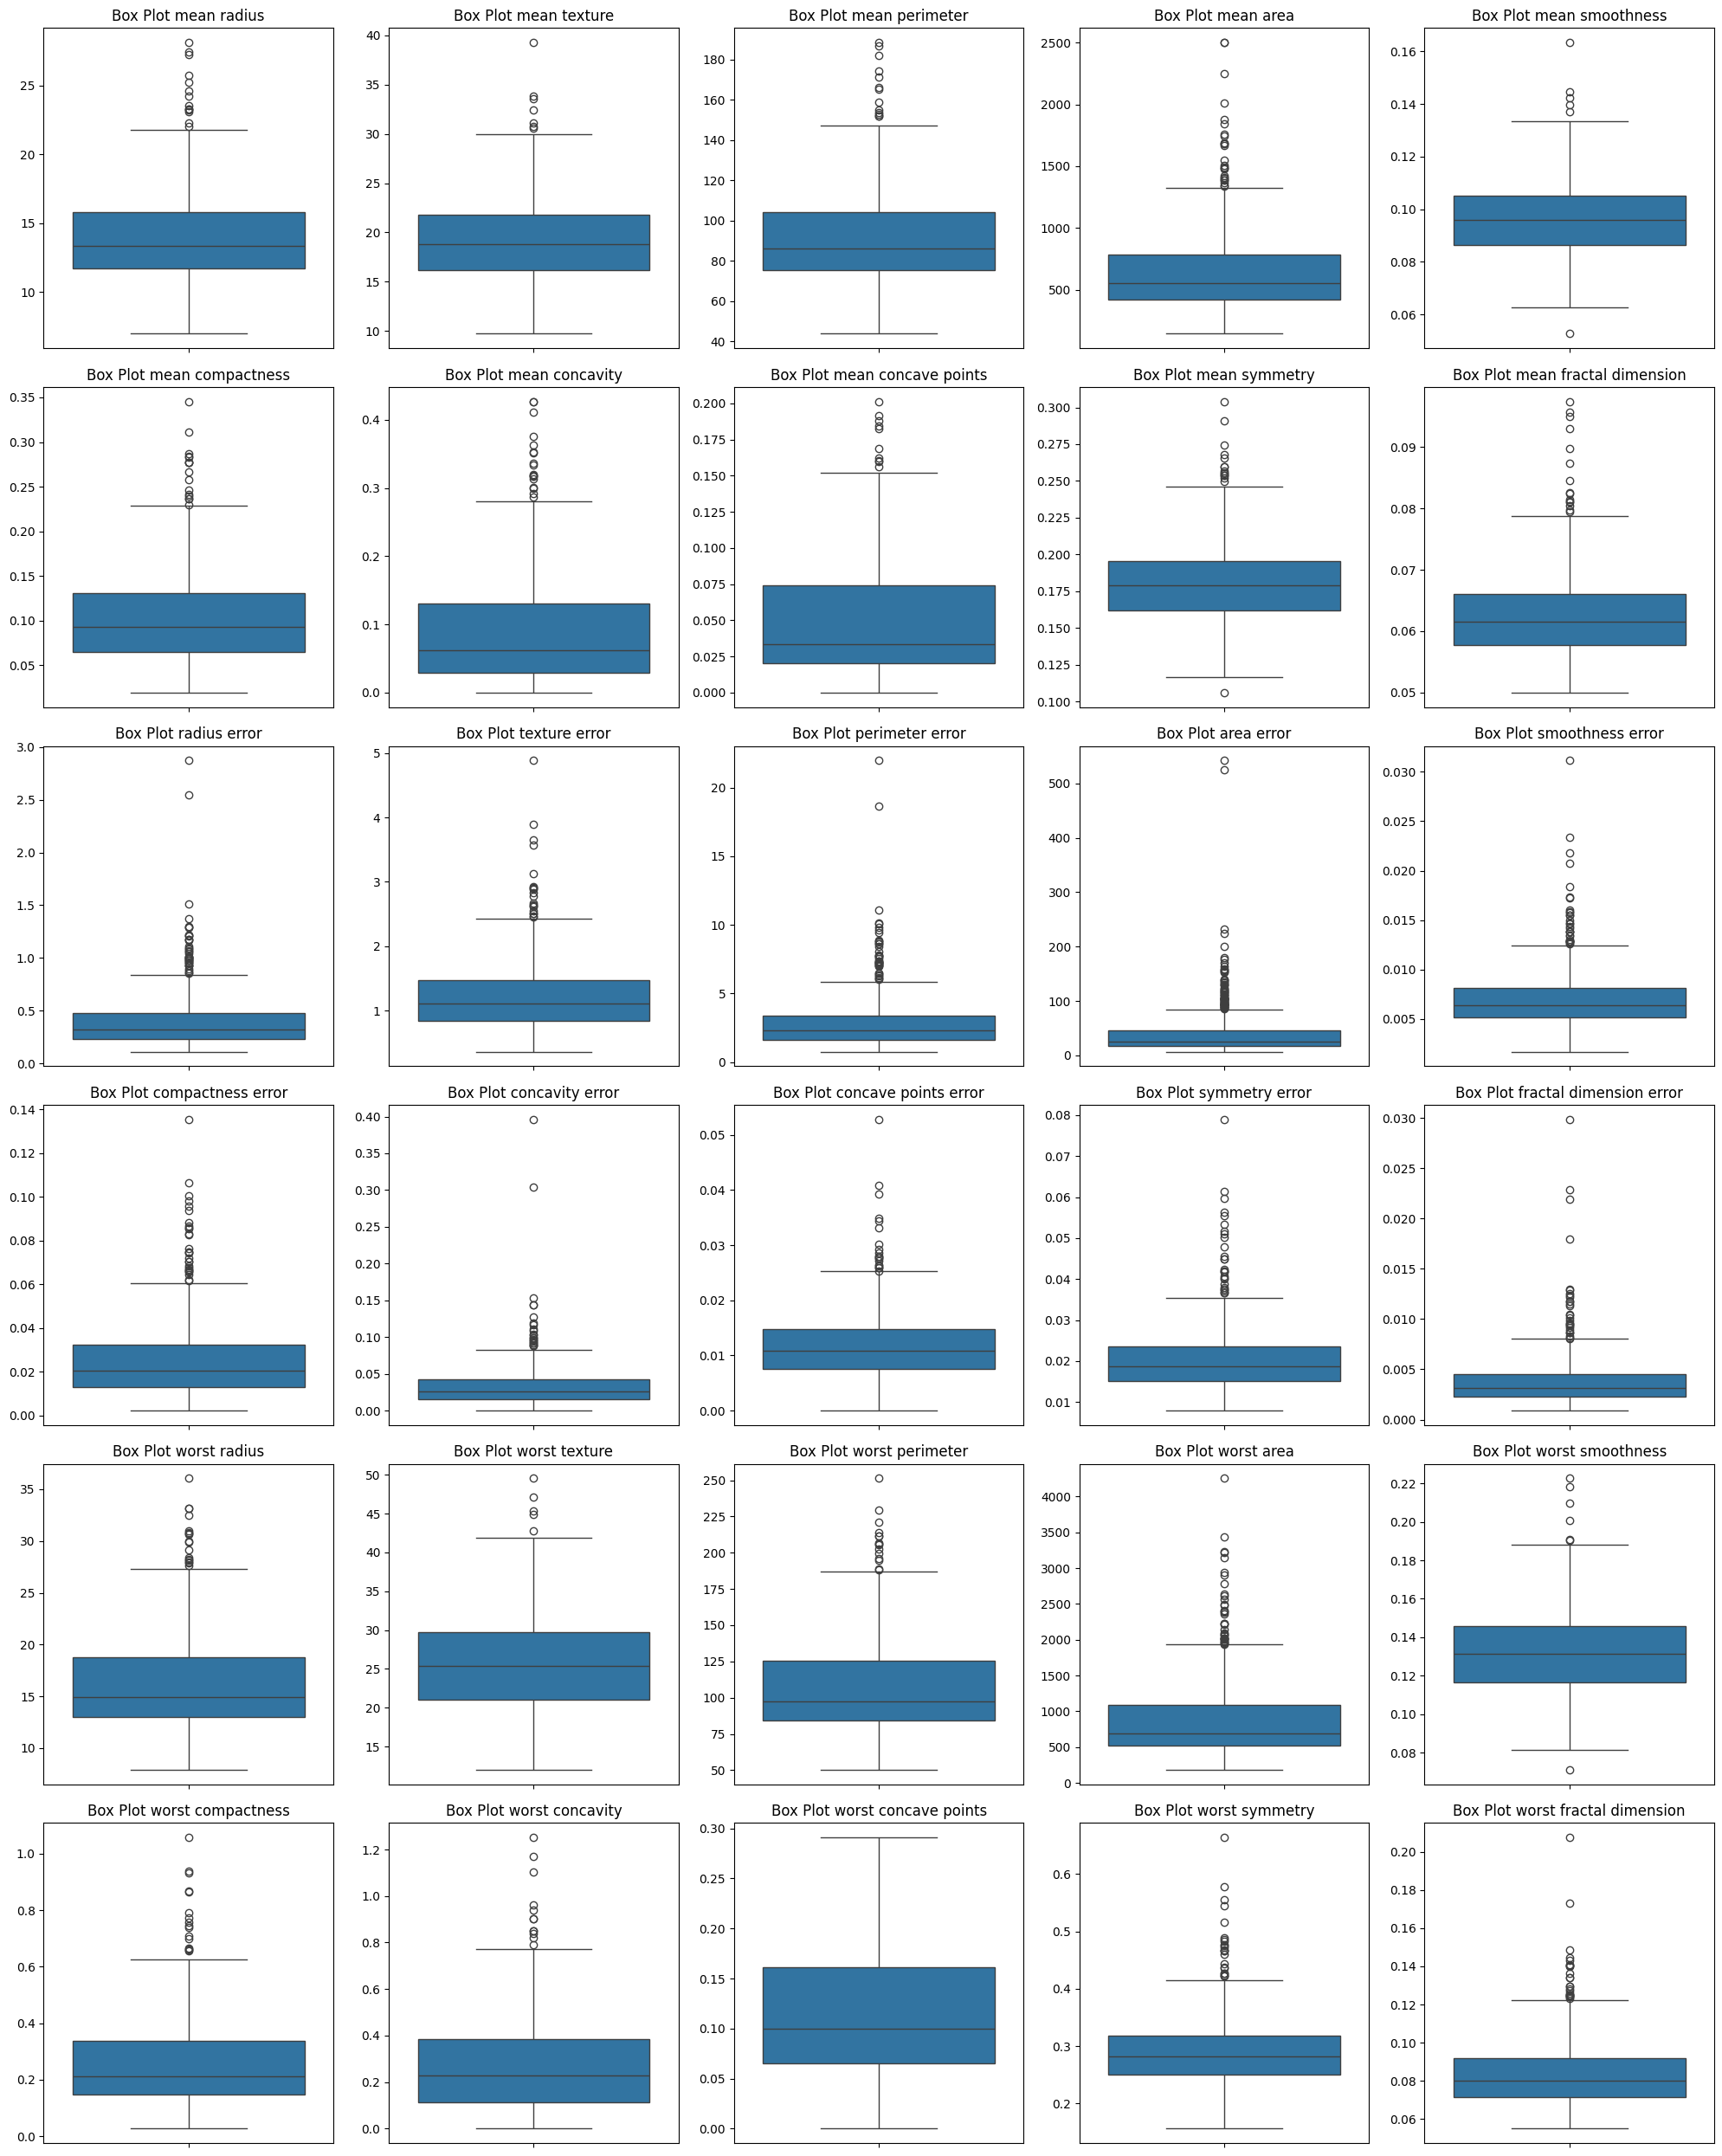

In [54]:
plt.figure(figsize=(20, 25))
for i, column in enumerate(X.columns):
    plt.subplot(6, 5, i + 1)
    sns.boxplot(y=X[column])
    plt.title(f'Box Plot {column}')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### Heatmap Korelasi Antar Variabel Numerik

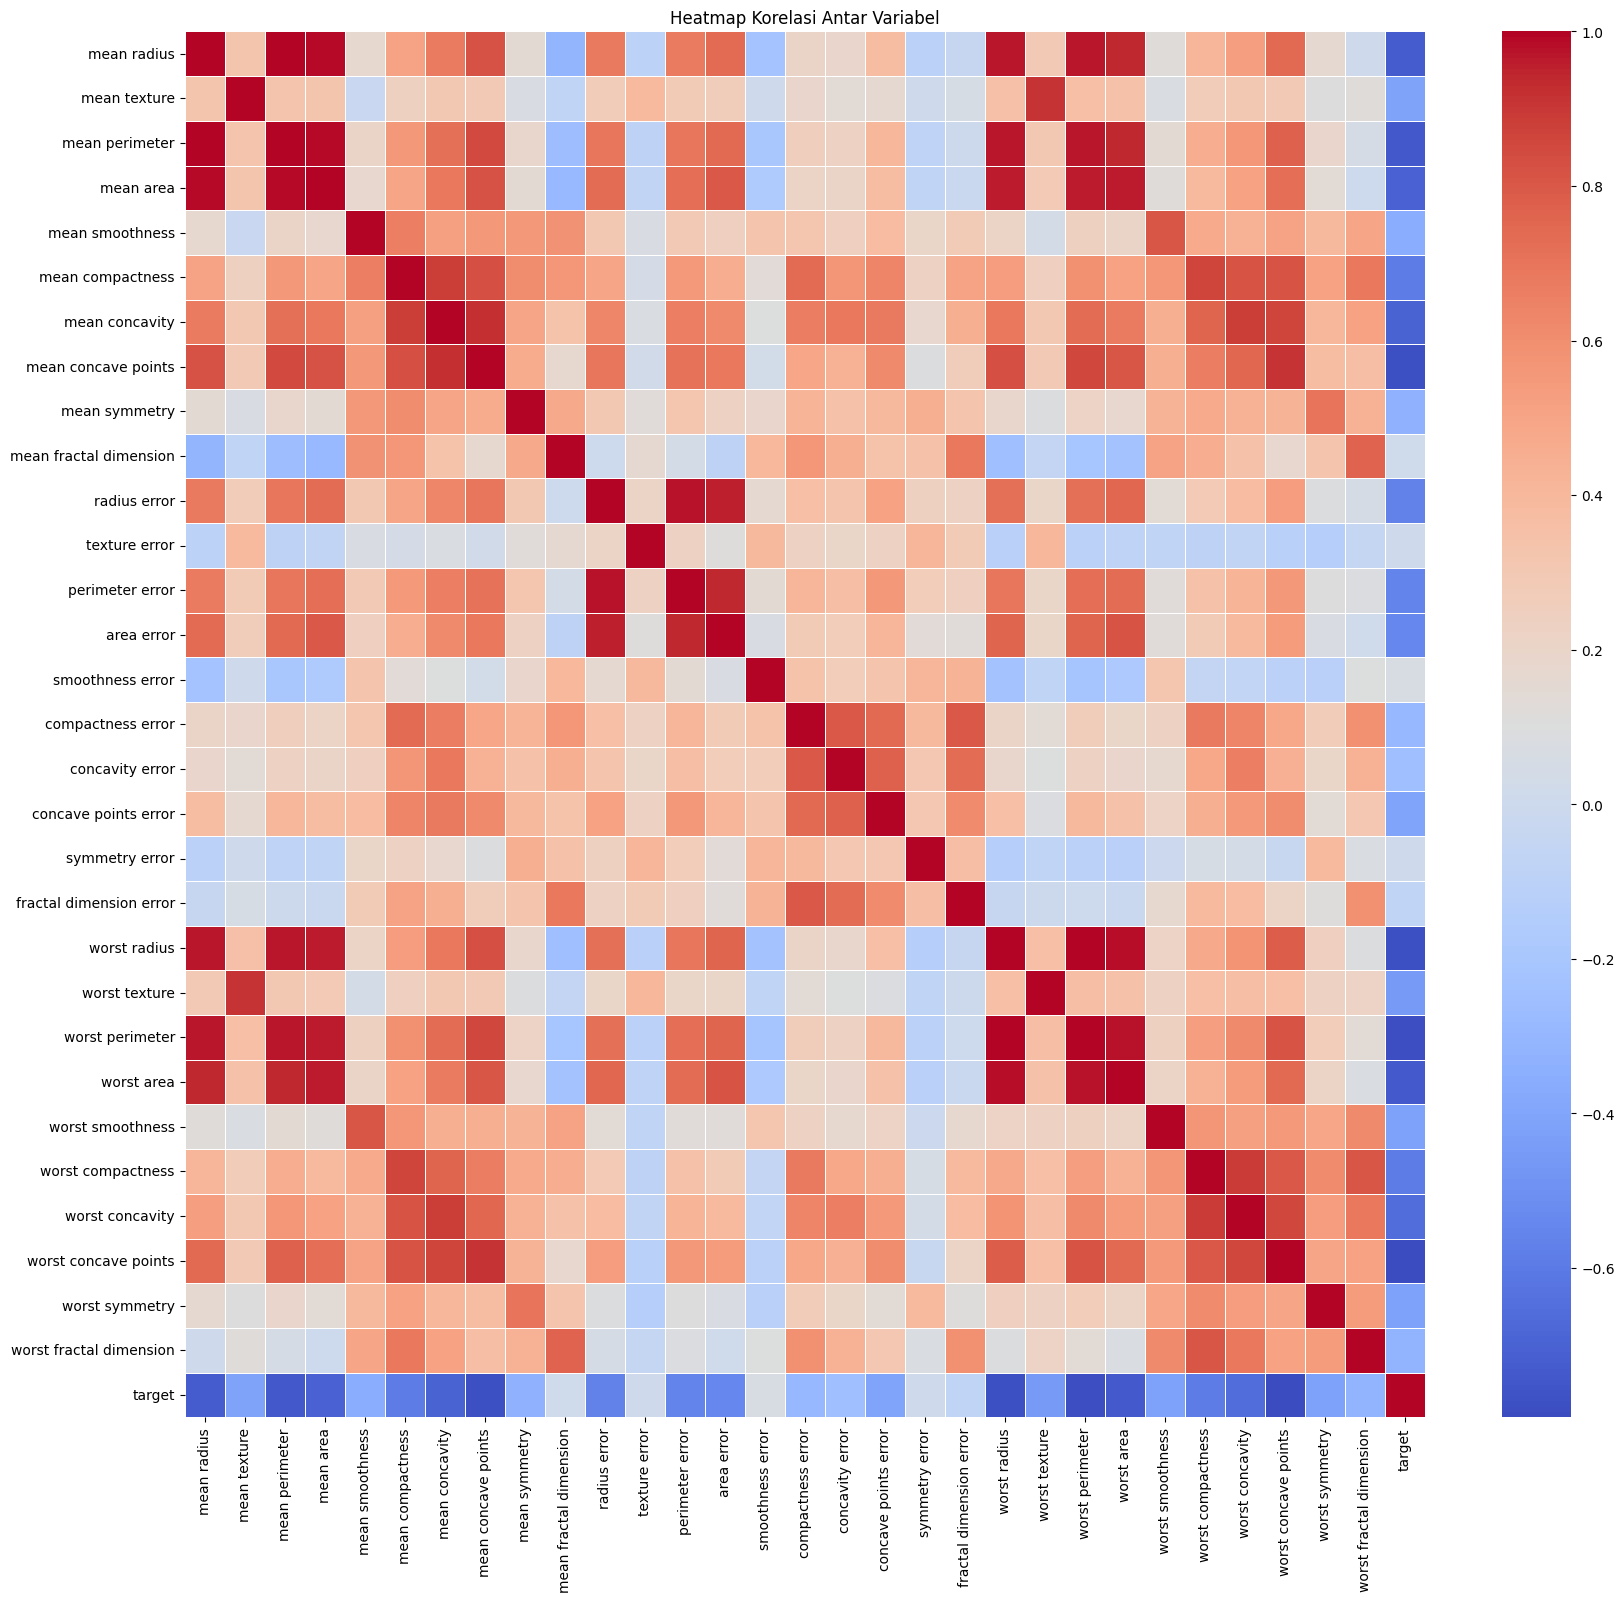

In [59]:
correlation_matrix = df.corr()

plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Antar Variabel')
plt.show()

## Langkah 3: Verifikasi & Penanganan Kualitas Data

### Pemeriksaan Awal: Missing Values dan Data Duplikat

In [60]:
print("Jumlah Missing Values per Kolom:")
print(df.isnull().sum())

print(f"\nJumlah Baris Duplikat: {df.duplicated().sum()}")

Jumlah Missing Values per Kolom:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Jumlah Baris Duplikat: 0


### Deteksi Outlier Menggunakan Interquartile Range (IQR)

In [55]:
outlier_indices = np.array([])

for column in X.columns:
    Q1 = X[column].quantile(0.25)
    Q3 = X[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    column_outliers = X[(X[column] < lower_bound) | (X[column] > upper_bound)].index
    outlier_indices = np.append(outlier_indices, column_outliers)

outlier_indices = np.unique(outlier_indices).astype(int)

print(f"Jumlah total baris yang terdeteksi sebagai outlier (menggunakan IQR): {len(outlier_indices)}")
print("Indeks baris yang terdeteksi sebagai outlier:")
print(outlier_indices)

Jumlah total baris yang terdeteksi sebagai outlier (menggunakan IQR): 171
Indeks baris yang terdeteksi sebagai outlier:
[  0   1   2   3   4   5   8   9  12  14  15  18  22  23  24  25  26  27
  30  31  33  34  35  38  41  42  53  56  60  62  63  68  70  71  72  76
  77  78  82  83  95 105 108 110 111 112 116 118 119 121 122 136 138 145
 146 147 150 151 152 156 161 162 164 168 173 176 180 181 185 190 192 196
 199 202 203 210 212 213 214 218 219 229 232 236 239 242 245 250 252 254
 256 257 258 259 262 265 272 273 275 288 290 300 302 314 318 323 329 332
 335 337 339 343 345 351 352 366 368 369 370 372 373 376 379 388 389 391
 393 400 416 417 424 430 433 443 449 450 455 460 461 465 468 469 471 473
 485 489 492 498 503 504 505 507 520 521 528 533 535 537 538 539 553 556
 557 559 561 562 563 564 565 567 568]


### Penanganan Kualitas: Hapus Duplikat dan Filter Outlier

In [61]:
df_cleaned = df.drop_duplicates()
print(f"Jumlah baris setelah menghapus duplikat: {len(df_cleaned)}")

df_filtered = df_cleaned.drop(outlier_indices, errors='ignore')

print(f"Jumlah baris setelah menghapus outlier: {len(df_filtered)}")

X_cleaned = df_filtered.drop('target', axis=1)
y_cleaned = df_filtered['target']

print(f"\nDimensi X_cleaned setelah penanganan kualitas: {X_cleaned.shape}")
print(f"Dimensi y_cleaned setelah penanganan kualitas: {y_cleaned.shape}")

Jumlah baris setelah menghapus duplikat: 569
Jumlah baris setelah menghapus outlier: 398

Dimensi X_cleaned setelah penanganan kualitas: (398, 30)
Dimensi y_cleaned setelah penanganan kualitas: (398,)


## Langkah 4: Kriteria & Teknik Pemilihan Data (Data Selection)

### Pembagian Dataset menjadi Data Training dan Data Testing (80:20) dengan Stratified Sampling

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42, stratify=y_cleaned)

print("--- Distribusi Kelas Target di Data Training dan Testing ---")
print("Data Training (80%):")
print(y_train.value_counts(normalize=True))
print("\nData Testing (20%):")
print(y_test.value_counts(normalize=True))

--- Distribusi Kelas Target di Data Training dan Testing ---
Data Training (80%):
target
1    0.754717
0    0.245283
Name: proportion, dtype: float64

Data Testing (20%):
target
1    0.75
0    0.25
Name: proportion, dtype: float64


## Langkah 5: Identifikasi Attributes dan Records

In [62]:
print("\n--- Data Training ---")
print(f"Jumlah Attributes: {X_train.shape[1]}")
print(f"Jumlah Records: {X_train.shape[0]}")

print("\n--- Data Testing ---")
print(f"Jumlah Attributes: {X_test.shape[1]}")
print(f"Jumlah Records: {X_test.shape[0]}")


--- Data Training ---
Jumlah Attributes: 30
Jumlah Records: 318

--- Data Testing ---
Jumlah Attributes: 30
Jumlah Records: 80


## Langkah 6: Integrasi & Formatting Data

### Simulasi Integrasi Data dan Pemeriksaan Kualitas

In [63]:
integrated_df = pd.concat([X_cleaned, y_cleaned], axis=1)

print("\n--- Setelah Simulasi Integrasi Data ---")
print(f"Dimensi data terintegrasi: {integrated_df.shape}")

print("\nInformasi Tipe Data Setelah Integrasi:")
integrated_df.info()

print("\nJumlah Missing Values Setelah Integrasi:")
print(integrated_df.isnull().sum().sum())


--- Setelah Simulasi Integrasi Data ---
Dimensi data terintegrasi: (398, 31)

Informasi Tipe Data Setelah Integrasi:
<class 'pandas.core.frame.DataFrame'>
Index: 398 entries, 6 to 566
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              398 non-null    float64
 1   mean texture             398 non-null    float64
 2   mean perimeter           398 non-null    float64
 3   mean area                398 non-null    float64
 4   mean smoothness          398 non-null    float64
 5   mean compactness         398 non-null    float64
 6   mean concavity           398 non-null    float64
 7   mean concave points      398 non-null    float64
 8   mean symmetry            398 non-null    float64
 9   mean fractal dimension   398 non-null    float64
 10  radius error             398 non-null    float64
 11  texture error            398 non-null    float64
 12  perimeter error      

### Formatting Nama Kolom

In [64]:
def clean_column_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = col.lower()
        new_col = new_col.replace(' ', '_')
        new_col = new_col.replace('(', '')
        new_col = new_col.replace(')', '')
        new_col = new_col.replace('.', '')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

integrated_df_formatted = clean_column_names(integrated_df.copy())

print("\n--- Nama Kolom Setelah Formatting --- ")
print(integrated_df_formatted.columns.tolist())

print("\nFormatting nama kolom berhasil diterapkan.")


--- Nama Kolom Setelah Formatting --- 
['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 'mean_compactness', 'mean_concavity', 'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension', 'radius_error', 'texture_error', 'perimeter_error', 'area_error', 'smoothness_error', 'compactness_error', 'concavity_error', 'concave_points_error', 'symmetry_error', 'fractal_dimension_error', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_smoothness', 'worst_compactness', 'worst_concavity', 'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension', 'target']

Formatting nama kolom berhasil diterapkan.


## Langkah 7: Evaluasi & Visualisasi Model

Setelah model dilatih, tahap ini bertujuan untuk memvalidasi performa model menggunakan data testing yang belum pernah dilihat sebelumnya. Kita akan melihat metrik klasifikasi standar serta visualisasi interaktif untuk memahami kekuatan dan kelemahan prediksi model.

### Analisis Laporan Klasifikasi (Precision, Recall, F1-Score)

Laporan ini memberikan gambaran mendalam tentang seberapa baik model membedakan antara kelas *Malignant* (0) dan *Benign* (1). Fokus utama kita adalah pada skor akurasi keseluruhan dan kemampuan model dalam mendeteksi kasus kanker ganas (*Recall* untuk Malignant).

*   **Recall (Sensitivitas):** Sangat krusial untuk meminimalkan *False Negative* (pasien kanker yang diprediksi sehat).
*   **Precision:** Penting untuk meminimalkan *False Positive* agar pasien tidak menjalani biopsi atau perawatan yang tidak diperlukan.
*   **F1-Score:** Memberikan keseimbangan antara keduanya, yang sangat berguna karena dataset ini memiliki sedikit ketidakseimbangan kelas.

In [69]:
report = classification_report(y_test, y_pred, target_names=['Malignant', 'Benign'])

print("--- Laporan Klasifikasi Mendalam ---")
print(report)

--- Laporan Klasifikasi Mendalam ---
              precision    recall  f1-score   support

   Malignant       0.88      0.70      0.78        20
      Benign       0.91      0.97      0.94        60

    accuracy                           0.90        80
   macro avg       0.89      0.83      0.86        80
weighted avg       0.90      0.90      0.90        80



In [66]:
counts_df = pd.DataFrame({
    'Jenis': ['Aktual', 'Aktual', 'Prediksi', 'Prediksi'],
    'Kelas': ['Malignant', 'Benign', 'Malignant', 'Benign'],
    'Jumlah': [
        (y_test == 0).sum(), (y_test == 1).sum(),
        (y_pred == 0).sum(), (y_pred == 1).sum()
    ]
})

fig_compare = px.bar(counts_df, x='Kelas', y='Jumlah', color='Jenis', barmode='group',
                     title='Perbandingan Distribusi Kelas: Aktual vs Prediksi (Akurasi 90%)',
                     labels={'Jumlah': 'Jumlah Sampel', 'Kelas': 'Kategori Kanker'},
                     color_discrete_sequence=['#636EFA', '#EF553B'])

fig_compare.update_layout(yaxis_range=[0, 70])
fig_compare.show()

In [57]:
pio.renderers.default = 'colab'

lgbm_model = lgb.LGBMClassifier(random_state=42, verbose=-1)
lgbm_model.fit(X_train, y_train)

y_pred = lgbm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

feature_imp = pd.DataFrame({'Value': lgbm_model.feature_importances_, 'Feature': X_train.columns})
feature_imp = feature_imp.sort_values(by="Value", ascending=False).head(10)

display(HTML(f"<h2 style='color:#2E86C1; text-align:center;'>Dashboard Evaluasi Model LightGBM</h2>"))
display(HTML(f"<h3 style='text-align:center;'>Akurasi Model: <span style='color:green;'>{accuracy:.2%}</span></h3>"))

fig_imp = px.bar(feature_imp, x='Value', y='Feature', orientation='h',
                 title='Top 10 Fitur',
                 labels={'Value': 'Skor', 'Feature': 'Fitur'},
                 color='Value', color_continuous_scale='Viridis')
fig_imp.show()

fig_cm = px.imshow(cm, text_auto=True,
                   labels=dict(x='Prediksi', y='Aktual', color='Jumlah'),
                   x=['Malignant', 'Benign'],
                   y=['Malignant', 'Benign'],
                   title='Confusion Matrix',
                   color_continuous_scale='Blues')
fig_cm.show()

print("\nTabel Sampel Prediksi (Acak):")
sample_indices = np.random.choice(X_test.index, size=5, replace=False)
sample_df = X_test.loc[sample_indices].copy()
sample_df['Aktual'] = y_test.loc[sample_indices]
sample_df['Prediksi'] = lgbm_model.predict(sample_df.drop(['Aktual'], axis=1, errors='ignore'))
display(sample_df[['mean radius', 'mean texture', 'Aktual', 'Prediksi']])


Tabel Sampel Prediksi (Acak):


,mean radius,mean texture,Aktual,Prediksi
451,19.59,25.00,0,0
125,13.85,17.21,1,1
377,13.46,28.21,1,1
85,18.46,18.52,0,0
453,14.53,13.98,1,1


In [70]:
model_filename = 'breast_cancer_lgbm_model.pkl'
joblib.dump(lgbm_model, model_filename)

print(f"Model berhasil disimpan sebagai: {model_filename}")

files.download(model_filename)

Model berhasil disimpan sebagai: breast_cancer_lgbm_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Cara Menggunakan Model Ini Kembali:
Untuk memprediksi dataset baru yang serupa, Anda cukup menggunakan kode berikut di notebook lain:
```python
import joblib
# Muat model
loaded_model = joblib.load('breast_cancer_lgbm_model.pkl')
# Lakukan prediksi
# new_predictions = loaded_model.predict(new_data)
```